# Vorticity Longitude-Time Cross Sections

Import statements

In [1]:
import matplotlib.pyplot as plt
import metpy.calc as mpcalc
import numpy as np
import xarray as xr
from metpy.units import units
import calendar

## Filenames

In [2]:
years = np.arange(2004, 2023 + 1, 1)

namelist_f = [
    f"/glade/work/smhenry/neuralGCM/sims/factual/ensmean_monthly/{yr}_ensmean_monthly_factual_raw.nc"
    for yr in years
]

## Concatenate data

In [3]:
u_data = xr.concat(
    [
        xr.open_dataset(namelist_f[yr]).u_component_of_wind.sel(level=850)
        for yr in range(len(years))
    ],
    dim="time",
)
v_data = xr.concat(
    [
        xr.open_dataset(namelist_f[yr]).v_component_of_wind.sel(level=850)
        for yr in range(len(years))
    ],
    dim="time",
)

## Calculate 850hPa vorticity

In [4]:
zeta = (
    mpcalc.vorticity(
        u_data * units("m/s"),
        v_data * units("m/s"),
    )
    .rename("Vorticity")
    .metpy.dequantify()
)
zeta.attrs["units"] = "s-1"  # adds units

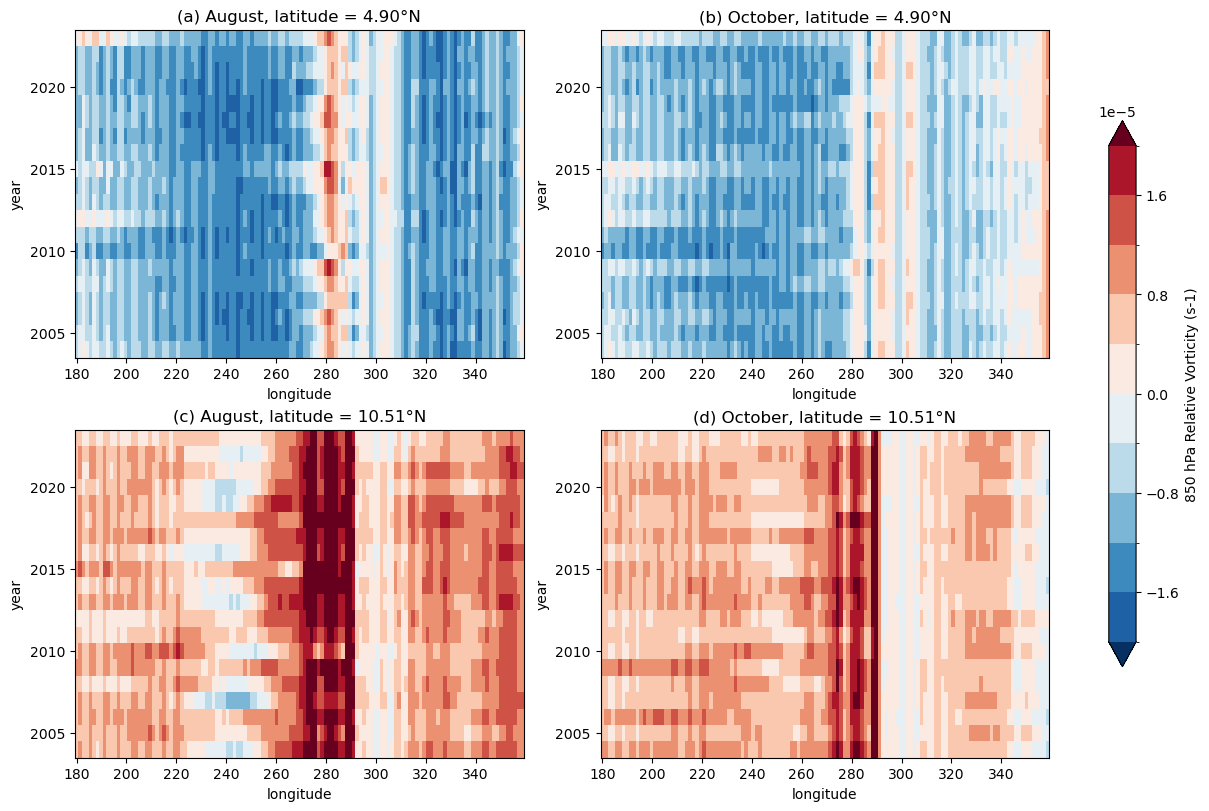

In [5]:
latitudes = [5, 5, 10, 10]
months = [8,10,8,10]
letters = ["a", "b", "c", "d"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

for ax, lat, mon, letter in zip(axes.flat, latitudes, months, letters):
    zeta_month = (
        zeta.sel(latitude=lat, method="nearest")
        .sel(longitude=slice(180, 360))
        .sel(time=zeta.time.dt.month == mon)
    )
    zeta_month_mean = zeta_month.groupby("time.year").mean(dim="time")
    
    pcm = zeta_month_mean.plot(
        x="longitude",
        y="year",
        levels=np.linspace(-2e-5, 2e-5, 11),
        extend="both",
        ax=ax,
        add_colorbar=False,
    )
    ax.set_title(f"({letter}) {calendar.month_name[mon]}, latitude = {float(zeta.sel(latitude=lat, method='nearest').latitude.values):.2f}°N")
    ax.set_yticks(np.arange(2005,2025,5))
                  
cbar = fig.colorbar(pcm, ax=axes, orientation="vertical", fraction=0.05, shrink=0.75)
cbar.set_label("850 hPa Relative Vorticity (s-1)")

plt.savefig("./figs/figure_SI_waves_AO.png",dpi=600)

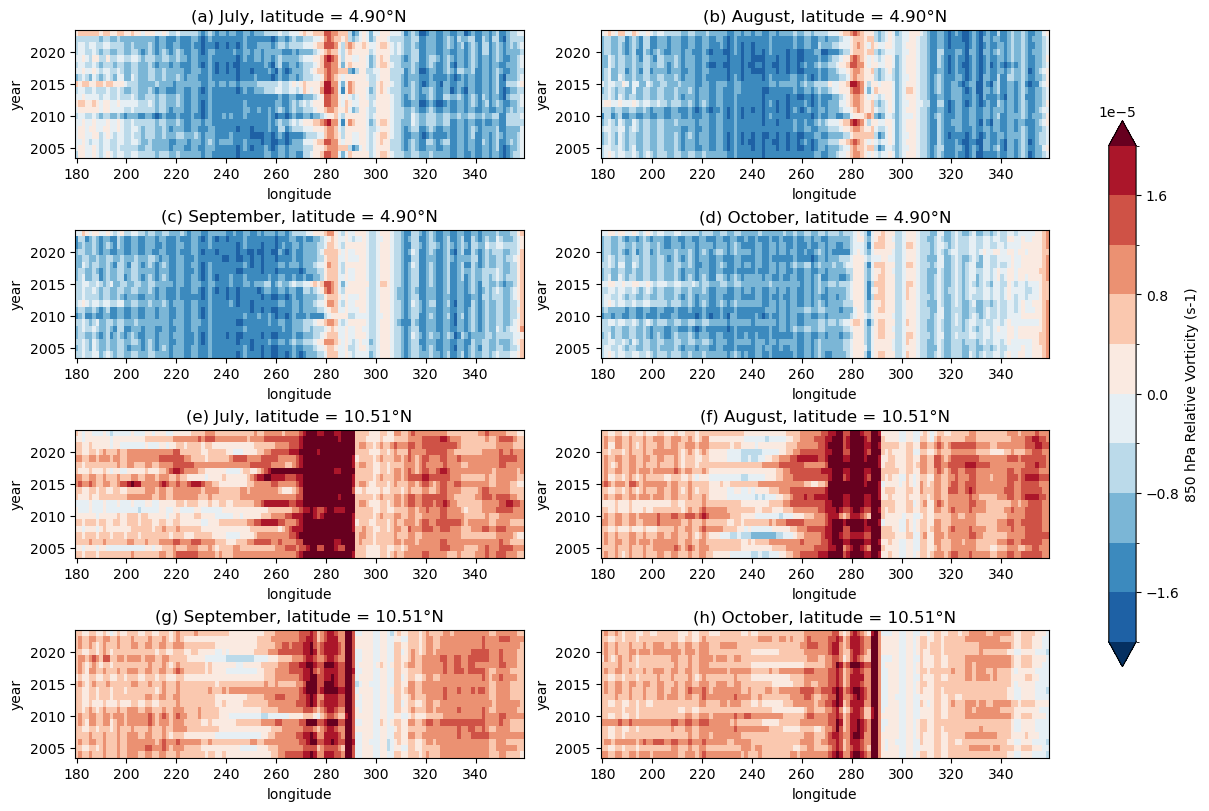

In [8]:
latitudes = [5, 5, 5, 5, 10, 10, 10, 10]
months = [7,8,9,10,7,8,9,10]
letters = ["a", "b", "c", "d","e","f","g","h"]

fig, axes = plt.subplots(4, 2, figsize=(12, 8), constrained_layout=True)

for ax, lat, mon, letter in zip(axes.flat, latitudes, months, letters):
    zeta_month = (
        zeta.sel(latitude=lat, method="nearest")
        .sel(longitude=slice(180, 360))
        .sel(time=zeta.time.dt.month == mon)
    )
    zeta_month_mean = zeta_month.groupby("time.year").mean(dim="time")
    
    pcm = zeta_month_mean.plot(
        x="longitude",
        y="year",
        levels=np.linspace(-2e-5, 2e-5, 11),
        extend="both",
        ax=ax,
        add_colorbar=False,
    )
    ax.set_title(f"({letter}) {calendar.month_name[mon]}, latitude = {float(zeta.sel(latitude=lat, method='nearest').latitude.values):.2f}°N")
    ax.set_yticks(np.arange(2005,2025,5))
                  
cbar = fig.colorbar(pcm, ax=axes, orientation="vertical", fraction=0.05, shrink=0.75)
cbar.set_label("850 hPa Relative Vorticity (s-1)")

plt.savefig("./figs/figure_SI_waves_JASO.png",dpi=600)